# 09_baseline_RL_v2 - Reinforcement Learning baseline con gestión operativa mínima

Este notebook implementa la segunda iteración del baseline de aprendizaje por refuerzo aplicado al trading algorítmico de DOGEUSDT.

La V1 validó una arquitectura RL mínima: entorno secuencial, acciones BUY/HOLD/SELL, Q-learning tabular y comparación contra Buy & Hold. Sin embargo, también mostró comportamientos poco realistas desde el punto de vista operativo, especialmente sobreoperación, acciones inválidas y exposición all-in.

Este notebook es autocontenido: vuelve a cargar datos, preparar el split, definir el entorno, entrenar y evaluar el agente. Esa repetición no pretende duplicar la V1, sino permitir que la V2 pueda ejecutarse y auditarse de forma independiente.

El objetivo de esta V2 no es construir una estrategia rentable, sino reducir comportamientos degenerados del agente mediante reglas operativas simples y trazables.

## Cambios principales respecto a V1

- Se añade una máscara de acciones válidas durante entrenamiento y evaluación
- BUY no se permite si el agente ya está en posición
- SELL no se permite si el agente está en cash
- Las acciones inválidas no se ejecutan; el entorno las transforma en HOLD y las registra como diagnóstico
- Se introduce un cooldown tras BUY o SELL
- Se usa position sizing parcial con el 50 % del capital disponible
- El reward incorpora penalización explícita por operación ejecutada
- Se añaden métricas de exposición, turnover y distribución de acciones
- Se cargan el summary y la curva de equity de V1 para comparar V1, V2 y Buy & Hold de forma visual y tabular

## Alcance del notebook

El entorno sigue siendo deliberadamente sencillo:

- Long-only
- Sin posiciones cortas
- Sin stop-loss ni take-profit
- Sin filtro de tendencia o volatilidad
- Sin optimización exhaustiva de hiperparámetros
- Q-learning tabular con discretización simple del estado

Esta versión debe leerse como una mejora operativa mínima sobre V1. El foco está en comprobar si restricciones razonables reducen rotación, exposición y drawdown, no en vender una máquina de imprimir dinero.

## Contexto metodológico

En reinforcement learning, el agente aprende interactuando con un entorno que ya integra decisiones, costes, reward y evolución del mercado. Por tanto, cada versión RL modifica tanto la política aprendida como las reglas del entorno.

La secuencia del proyecto queda organizada así:

- V1: Entorno RL mínimo y funcional
- V2: Gestión operativa básica para reducir comportamientos degenerados
- V3: Filtros de mercado y control defensivo del riesgo

Esta progresión permite construir una narrativa experimental clara: no se asume que RL sea superior por defecto, sino que se evalúa qué ocurre al introducir restricciones cada vez más realistas.


In [1]:
# ============================================================
# Imports and global configuration
# Se cargan las librerías principales y se define la configuración general del experimento RL V2.
# La configuración mantiene Q-learning tabular para facilitar la comparación con V1 y añade restricciones operativas mínimas.
# ============================================================

from pathlib import Path
from collections import defaultdict
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

try:
    import gymnasium as gym
    from gymnasium import spaces
    GYM_BACKEND = "gymnasium"
except ImportError:
    try:
        import gym
        from gym import spaces
        GYM_BACKEND = "gym"
    except ImportError as exc:
        raise ImportError(
            "No se ha encontrado gymnasium ni gym. Instala una de estas dependencias antes de ejecutar el notebook: "
            "pip install gymnasium"
        ) from exc

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

INITIAL_BALANCE = 1000.0
FEE_RATE = 0.001
SLIPPAGE_RATE = 0.0005
TRAIN_FRACTION = 0.80
MAX_TRAIN_EPISODE_STEPS = 2_000
N_EPISODES = 30

POSITION_SIZE_PCT = 0.50
COOLDOWN_STEPS = 3
TRADE_REWARD_PENALTY = 0.00005
INVALID_ACTION_PENALTY = 0.00010

NOTEBOOK_ID = "09_baseline_RL_v2"

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Gym backend: {GYM_BACKEND}")
print(f"Results directory: {RESULTS_DIR.resolve()}")


Gym backend: gymnasium
Results directory: C:\Users\elwya\Documents\programacion\python\jupyter notebook\M10\TFM\Repository\cryptobot-tfm\results


In [2]:
# ============================================================
# Load engineered DOGEUSDT dataset
# Se carga el dataset enriquecido generado en el pipeline de feature engineering.
# ============================================================

DATA_PATH = Path("../data/processed/DOGEUSDT_5m_binance_2017_2026_features.csv")

if DATA_PATH is None:
    raise FileNotFoundError(
        "No se encontró el dataset enriquecido. Revisa la ruta definida en DATA_PATH."
    )

df = pd.read_csv(DATA_PATH)

if "open_time" in df.columns:
    df["open_time"] = pd.to_datetime(df["open_time"])
    df = df.sort_values("open_time").reset_index(drop=True)

print(f"Dataset loaded from: {DATA_PATH}")
print(f"Shape: {df.shape}")
display(df.head())

Dataset loaded from: ..\data\processed\DOGEUSDT_5m_binance_2017_2026_features.csv
Shape: (723080, 54)


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,...,price_position_in_recent_range,recent_support,recent_resistance,dist_to_nearest_support,dist_to_nearest_resistance,near_support,near_resistance,support_strength,resistance_strength,touch_count_near_level
0,2019-07-06 11:55:00,0.003630,0.003644,0.003630,0.003635,472036.0,2019-07-06 11:59:59.999,1718.044681,24,405943.0,...,0.081048,0.00355,0.004600,0.023411,0.265440,0,0,0.0,0.0,0.0
1,2019-07-06 12:00:00,0.003632,0.003638,0.003629,0.003637,799853.0,2019-07-06 12:04:59.999,2908.008956,18,292138.0,...,0.109846,0.00355,0.004340,0.023867,0.193412,0,0,0.0,0.0,0.0
2,2019-07-06 12:05:00,0.003634,0.003637,0.003625,0.003637,2176492.0,2019-07-06 12:09:59.999,7909.776304,42,1028365.0,...,0.166956,0.00355,0.004069,0.023813,0.118820,0,0,0.0,0.0,0.0
3,2019-07-06 12:10:00,0.003636,0.003636,0.003620,0.003620,618720.0,2019-07-06 12:14:59.999,2240.639784,16,33792.0,...,0.168759,0.00355,0.003964,0.019310,0.095113,0,0,0.0,0.0,0.0
4,2019-07-06 12:15:00,0.003621,0.003627,0.003610,0.003611,1808302.0,2019-07-06 12:19:59.999,6538.506892,30,450314.0,...,0.147272,0.00355,0.003964,0.016893,0.097812,0,0,0.0,0.0,0.0


In [3]:
# ============================================================
# Dataset validation and feature selection
# Se validan las columnas necesarias y se seleccionan únicamente variables disponibles en el pasado o presente para evitar leakage.
# Las columnas target futuras se excluyen explícitamente porque el agente no debe observar información del futuro.
# ============================================================

required_columns = ["close"]
missing_required = [col for col in required_columns if col not in df.columns]

if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

excluded_columns = [
    "open_time",
    "close_time",
    "future_close_1",
    "future_return_1",
    "up_1",
    "future_close_3",
    "future_return_3",
    "up_3",
    "future_close_6",
    "future_return_6",
    "up_6",
    "future_close_12",
    "future_return_12",
    "up_12",
]

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in excluded_columns and col != "close"]

preferred_rl_features = [
    "return_prev_1",
    "log_return_prev_1",
    "ema10_ema50_ratio",
    "ema50_ema200_ratio",
    "sma20_ema50_ratio",
    "volatility_1h",
    "zscore_close_1h",
    "rsi_14",
    "macd",
    "macd_signal",
    "macd_hist",
    "bb_width",
    "bb_percent",
    "atr_14",
    "price_position_in_recent_range",
    "dist_to_nearest_support",
    "dist_to_nearest_resistance",
    "near_support",
    "near_resistance",
    "support_strength",
    "resistance_strength",
    "touch_count_near_level",
]

feature_cols = [col for col in preferred_rl_features if col in feature_cols]

if len(feature_cols) == 0:
    raise ValueError("No se encontraron features válidas para el entorno RL.")

rl_df = df[["open_time", "close"] + feature_cols].copy() if "open_time" in df.columns else df[["close"] + feature_cols].copy()
rl_df = rl_df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

print(f"Number of selected RL features: {len(feature_cols)}")
display(pd.DataFrame({"feature": feature_cols}))
print(f"RL dataset shape after cleaning: {rl_df.shape}")


Number of selected RL features: 22


,feature
0,return_prev_1
1,log_return_prev_1
2,ema10_ema50_ratio
3,ema50_ema200_ratio
4,sma20_ema50_ratio
5,volatility_1h
6,zscore_close_1h
7,rsi_14
8,macd
9,macd_signal


RL dataset shape after cleaning: (723080, 24)


In [4]:
# ============================================================
# Temporal train-test split and feature scaling
# Se separa el dataset en entrenamiento y test siguiendo orden temporal, evitando mezclar observaciones futuras en el entrenamiento.
# El escalado se ajusta solo con train y después se aplica a test para evitar contaminación temporal.
# ============================================================

split_idx = int(len(rl_df) * TRAIN_FRACTION)
train_df = rl_df.iloc[:split_idx].copy().reset_index(drop=True)
test_df = rl_df.iloc[split_idx:].copy().reset_index(drop=True)

scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_df[feature_cols])
test_features_scaled = scaler.transform(test_df[feature_cols])

train_scaled_df = train_df.copy()
test_scaled_df = test_df.copy()
train_scaled_df[feature_cols] = train_features_scaled
test_scaled_df[feature_cols] = test_features_scaled

split_summary = {
    "total_rows": len(rl_df),
    "train_rows": len(train_scaled_df),
    "test_rows": len(test_scaled_df),
    "train_start": train_df["open_time"].iloc[0] if "open_time" in train_df.columns else None,
    "train_end": train_df["open_time"].iloc[-1] if "open_time" in train_df.columns else None,
    "test_start": test_df["open_time"].iloc[0] if "open_time" in test_df.columns else None,
    "test_end": test_df["open_time"].iloc[-1] if "open_time" in test_df.columns else None,
}

split_summary_df = pd.DataFrame([split_summary])
display(split_summary_df)


,total_rows,train_rows,test_rows,train_start,train_end,test_start,test_end
0,723080,578464,144616,2019-07-06 11:55:00,2025-01-06 06:50:00,2025-01-06 06:55:00,2026-05-23 10:10:00


## Comentarios - Split temporal

El dataset procesado contiene 723.080 observaciones tras la limpieza previa, con una partición temporal 80/20.

El tramo de entrenamiento cubre desde 2019-07-06 hasta 2025-01-06, mientras que el tramo de test se reserva desde 2025-01-06 hasta 2026-05-23.

Esta separación mantiene la lógica temporal necesaria para evitar leakage: el agente se entrena únicamente con datos pasados y se evalúa sobre un periodo posterior no utilizado durante el aprendizaje.

El periodo de test incluye un tramo amplio y reciente del mercado, por lo que la evaluación permite observar si la política aprendida generaliza fuera del histórico usado para actualizar la Q-table.


In [5]:
# ============================================================
# Trading environment definition with basic operational constraints
# Se define un entorno compatible con Gym para simular decisiones secuenciales de trading con acciones BUY, HOLD y SELL.
# La V2 no ejecuta acciones inválidas: si recibe una acción no permitida, la convierte en HOLD, la registra y aplica una penalización diagnóstica.
# ============================================================

class DogeTradingEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(
        self,
        data,
        feature_columns,
        initial_balance=1000.0,
        fee_rate=0.001,
        slippage_rate=0.0005,
        position_size_pct=0.50,
        cooldown_steps=3,
        trade_reward_penalty=0.00005,
        invalid_action_penalty=0.00010,
        random_start=False,
        max_episode_steps=None,
        seed=42,
    ):
        super().__init__()
        self.data = data.reset_index(drop=True).copy()
        self.feature_columns = feature_columns
        self.initial_balance = float(initial_balance)
        self.fee_rate = float(fee_rate)
        self.slippage_rate = float(slippage_rate)
        self.position_size_pct = float(position_size_pct)
        self.cooldown_steps = int(cooldown_steps)
        self.trade_reward_penalty = float(trade_reward_penalty)
        self.invalid_action_penalty = float(invalid_action_penalty)
        self.random_start = random_start
        self.max_episode_steps = max_episode_steps
        self.rng = np.random.default_rng(seed)

        if not 0 < self.position_size_pct <= 1:
            raise ValueError("position_size_pct debe estar en el intervalo (0, 1].")

        self.action_space = spaces.Discrete(3)
        obs_size = len(self.feature_columns) + 3
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(obs_size,), dtype=np.float32)

        self.reset()

    def _get_price(self):
        return float(self.data.loc[self.current_step, "close"])

    def _get_equity(self):
        price = self._get_price()
        return self.cash + self.asset_units * price

    def _get_observation(self):
        features = self.data.loc[self.current_step, self.feature_columns].to_numpy(dtype=np.float32)
        equity = max(self._get_equity(), 1e-12)
        position_flag = np.float32(1.0 if self.asset_units > 0 else 0.0)
        cash_ratio = np.float32(self.cash / equity)
        cooldown_ratio = np.float32(self.cooldown_remaining / max(self.cooldown_steps, 1))
        return np.concatenate([features, [position_flag, cash_ratio, cooldown_ratio]]).astype(np.float32)

    def get_valid_actions(self):
        valid_actions = [0]

        can_trade = self.cooldown_remaining == 0
        has_position = self.asset_units > 0
        has_cash = self.cash > 1e-12

        if can_trade and not has_position and has_cash:
            valid_actions.append(1)

        if can_trade and has_position:
            valid_actions.append(2)

        return valid_actions

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        if seed is not None:
            self.rng = np.random.default_rng(seed)

        max_start = max(1, len(self.data) - (self.max_episode_steps or len(self.data)) - 2)
        if self.random_start and max_start > 1:
            self.current_step = int(self.rng.integers(0, max_start))
        else:
            self.current_step = 0

        self.start_step = self.current_step
        self.cash = self.initial_balance
        self.asset_units = 0.0
        self.cooldown_remaining = 0
        self.last_equity = self.initial_balance
        self.trade_log = []
        self.equity_curve = []
        self.action_history = []
        self.executed_action_history = []
        self.position_history = []
        self.exposure_history = []
        self.invalid_action_count = 0

        obs = self._get_observation()
        info = {"equity": self.last_equity, "valid_actions": self.get_valid_actions()}
        return obs, info

    def step(self, action):
        action = int(action)
        price = self._get_price()
        previous_equity = max(self._get_equity(), 1e-12)
        valid_actions = self.get_valid_actions()
        invalid_action = action not in valid_actions
        executed_trade = "HOLD"

        if invalid_action:
            self.invalid_action_count += 1
            action_to_execute = 0
        else:
            action_to_execute = action

        if action_to_execute == 1:
            execution_price = price * (1 + self.slippage_rate)
            cash_to_invest = self.cash * self.position_size_pct
            cash_after_fee = cash_to_invest * (1 - self.fee_rate)
            bought_units = cash_after_fee / execution_price

            self.cash -= cash_to_invest
            self.asset_units += bought_units
            self.cooldown_remaining = self.cooldown_steps
            executed_trade = "BUY"
            self.trade_log.append({"step": self.current_step, "action": executed_trade, "price": price})

        elif action_to_execute == 2:
            execution_price = price * (1 - self.slippage_rate)
            gross_cash = self.asset_units * execution_price

            self.cash += gross_cash * (1 - self.fee_rate)
            self.asset_units = 0.0
            self.cooldown_remaining = self.cooldown_steps
            executed_trade = "SELL"
            self.trade_log.append({"step": self.current_step, "action": executed_trade, "price": price})

        elif self.cooldown_remaining > 0:
            self.cooldown_remaining -= 1

        self.current_step += 1

        reached_end = self.current_step >= len(self.data) - 1
        reached_max_steps = self.max_episode_steps is not None and (self.current_step - self.start_step) >= self.max_episode_steps
        terminated = reached_end
        truncated = bool(reached_max_steps and not reached_end)

        current_equity = max(self._get_equity(), 1e-12)
        reward = np.log(current_equity / previous_equity)

        if executed_trade != "HOLD":
            reward -= self.trade_reward_penalty

        if invalid_action:
            reward -= self.invalid_action_penalty

        exposure = (self.asset_units * self._get_price()) / current_equity if current_equity > 0 else 0.0

        self.last_equity = current_equity
        self.equity_curve.append(current_equity)
        self.action_history.append(action)
        self.executed_action_history.append(action_to_execute)
        self.position_history.append(1 if self.asset_units > 0 else 0)
        self.exposure_history.append(exposure)

        obs = self._get_observation()
        info = {
            "equity": current_equity,
            "price": self._get_price(),
            "executed_trade": executed_trade,
            "requested_action": action,
            "executed_action": action_to_execute,
            "invalid_action": invalid_action,
            "position": 1 if self.asset_units > 0 else 0,
            "cash": self.cash,
            "asset_units": self.asset_units,
            "exposure": exposure,
            "cooldown_remaining": self.cooldown_remaining,
            "valid_actions": self.get_valid_actions(),
        }

        return obs, float(reward), terminated, truncated, info


In [6]:
# ============================================================
# Environment smoke test without valid-action masking
# Se ejecuta una prueba corta con acciones aleatorias sin máscara para validar que el entorno avanza, calcula equity y registra operaciones sin errores.
# Esta prueba fuerza acciones inválidas a propósito para comprobar que el entorno las registra y las transforma en HOLD.
# ============================================================

env_check = DogeTradingEnv(
    train_scaled_df,
    feature_cols,
    initial_balance=INITIAL_BALANCE,
    fee_rate=FEE_RATE,
    slippage_rate=SLIPPAGE_RATE,
    position_size_pct=POSITION_SIZE_PCT,
    cooldown_steps=COOLDOWN_STEPS,
    trade_reward_penalty=TRADE_REWARD_PENALTY,
    invalid_action_penalty=INVALID_ACTION_PENALTY,
    random_start=True,
    max_episode_steps=100,
    seed=RANDOM_STATE,
)

obs, info = env_check.reset(seed=RANDOM_STATE)
smoke_rewards = []

for _ in range(100):
    action = env_check.action_space.sample()
    obs, reward, terminated, truncated, info = env_check.step(action)
    smoke_rewards.append(reward)
    if terminated or truncated:
        break

smoke_summary = {
    "steps_executed": len(smoke_rewards),
    "final_equity": info["equity"],
    "total_reward": np.sum(smoke_rewards),
    "num_logged_trades": len(env_check.trade_log),
    "invalid_actions": env_check.invalid_action_count,
    "mean_exposure": np.mean(env_check.exposure_history) if env_check.exposure_history else 0.0,
    "final_cooldown_remaining": info["cooldown_remaining"],
}

smoke_summary_df = pd.DataFrame([smoke_summary])
display(smoke_summary_df)


,steps_executed,final_equity,total_reward,num_logged_trades,invalid_actions,mean_exposure,final_cooldown_remaining
0,100,985.422142,-0.020985,16,55,0.239805,0


## Comentarios - Smoke test del entorno

El smoke test usa `env_check.action_space.sample()`, es decir, acciones aleatorias sin consultar `get_valid_actions()`. Por eso aparecen 51 acciones inválidas en solo 100 pasos.

Esto no contradice la máscara de acciones válidas. En esta celda todavía no se está usando la política Q-learning; se está probando la robustez interna del entorno cuando recibe acciones absurdas. El entorno no las ejecuta: las convierte en HOLD, las registra como `invalid_action` y aplica la penalización configurada.

Los 13 trades del smoke test tampoco son comparables con el entrenamiento. Aquí solo hay 100 pasos, acciones completamente aleatorias, cooldown y restricciones de posición. En el entrenamiento, cada episodio tiene hasta 2.000 pasos y la acción se elige con epsilon-greedy sobre acciones válidas.

La lectura correcta es que el smoke test valida las defensas del entorno, mientras que el entrenamiento y el test validan la política con máscara de acciones válidas.


In [7]:
# ============================================================
# Q-learning helper functions with valid-action masking
# Se implementa una política Q-learning tabular sobre una discretización sencilla del estado observado por el entorno.
# La selección de acciones usa una máscara de acciones válidas para reducir decisiones sin valor operativo.
# ============================================================

selected_state_features = [
    col for col in [
        "return_prev_1",
        "zscore_close_1h",
        "rsi_14",
        "macd_hist",
        "bb_percent",
        "price_position_in_recent_range",
        "volatility_1h",
    ]
    if col in feature_cols
]

state_feature_indices = [feature_cols.index(col) for col in selected_state_features]
position_index = len(feature_cols)
cash_ratio_index = len(feature_cols) + 1
cooldown_index = len(feature_cols) + 2

state_bins = np.array([-1.5, -0.75, 0.0, 0.75, 1.5])


def discretize_observation(obs):
    feature_state = tuple(np.digitize(obs[idx], state_bins) for idx in state_feature_indices)
    position_state = int(obs[position_index] > 0.5)
    cash_state = int(obs[cash_ratio_index] > 0.5)
    cooldown_state = int(obs[cooldown_index] > 0.0)
    return feature_state + (position_state, cash_state, cooldown_state)


def choose_action(q_table, state, epsilon, valid_actions, n_actions=3):
    valid_actions = list(valid_actions)

    if np.random.random() < epsilon:
        return int(np.random.choice(valid_actions))

    q_values = q_table[state].copy()
    invalid_actions = [action for action in range(n_actions) if action not in valid_actions]
    q_values[invalid_actions] = -np.inf
    return int(np.argmax(q_values))


print(f"State features used by Q-learning: {selected_state_features}")


State features used by Q-learning: ['return_prev_1', 'zscore_close_1h', 'rsi_14', 'macd_hist', 'bb_percent', 'price_position_in_recent_range', 'volatility_1h']


In [8]:
# ============================================================
# Train tabular Q-learning agent
# Se entrena un agente Q-learning durante un número reducido de episodios con inicios aleatorios dentro del tramo de entrenamiento.
# La V2 aprende usando únicamente acciones válidas y registra métricas operativas adicionales.
# ============================================================

train_env = DogeTradingEnv(
    train_scaled_df,
    feature_cols,
    initial_balance=INITIAL_BALANCE,
    fee_rate=FEE_RATE,
    slippage_rate=SLIPPAGE_RATE,
    position_size_pct=POSITION_SIZE_PCT,
    cooldown_steps=COOLDOWN_STEPS,
    trade_reward_penalty=TRADE_REWARD_PENALTY,
    invalid_action_penalty=INVALID_ACTION_PENALTY,
    random_start=True,
    max_episode_steps=MAX_TRAIN_EPISODE_STEPS,
    seed=RANDOM_STATE,
)

q_table = defaultdict(lambda: np.zeros(train_env.action_space.n, dtype=np.float64))

alpha = 0.08
gamma = 0.95
epsilon_start = 1.00
epsilon_end = 0.05
epsilon_decay = 0.92

episode_metrics = []
epsilon = epsilon_start

for episode in range(1, N_EPISODES + 1):
    obs, info = train_env.reset(seed=RANDOM_STATE + episode)
    state = discretize_observation(obs)
    total_reward = 0.0
    done = False
    steps = 0

    while not done:
        valid_actions = train_env.get_valid_actions()
        action = choose_action(q_table, state, epsilon, valid_actions, train_env.action_space.n)
        next_obs, reward, terminated, truncated, info = train_env.step(action)
        next_state = discretize_observation(next_obs)

        next_valid_actions = train_env.get_valid_actions()
        next_q_values = q_table[next_state][next_valid_actions]
        best_next_q = np.max(next_q_values)

        q_table[state][action] += alpha * (reward + gamma * best_next_q - q_table[state][action])

        state = next_state
        total_reward += reward
        steps += 1
        done = terminated or truncated

    episode_metrics.append({
        "episode": episode,
        "steps": steps,
        "total_reward": total_reward,
        "final_equity": info["equity"],
        "epsilon": epsilon,
        "num_trades": len(train_env.trade_log),
        "invalid_actions": train_env.invalid_action_count,
        "mean_exposure": np.mean(train_env.exposure_history) if train_env.exposure_history else 0.0,
    })

    epsilon = max(epsilon_end, epsilon * epsilon_decay)

training_metrics_df = pd.DataFrame(episode_metrics)
display(training_metrics_df.tail(10))
print(f"Number of learned states: {len(q_table)}")


,episode,steps,total_reward,final_equity,epsilon,num_trades,invalid_actions,mean_exposure
20,21,2000,-0.050584,959.172989,0.188693,178,0,0.201469
21,22,2000,-0.122627,893.394410,0.173598,198,0,0.180798
22,23,2000,-0.127551,887.851590,0.159710,172,0,0.204813
23,24,2000,-0.091729,920.140520,0.146933,170,0,0.181663
24,25,2000,-0.138271,878.032767,0.135179,164,0,0.173628
25,26,2000,-0.099426,912.354669,0.124364,154,0,0.189122
26,27,2000,-0.105260,907.138185,0.114415,156,0,0.156203
27,28,2000,-0.127326,886.498081,0.105262,137,0,0.160359
28,29,2000,-0.192262,831.302373,0.096841,150,0,0.156472
29,30,2000,-0.086919,923.514096,0.089094,147,0,0.153719


Number of learned states: 14695


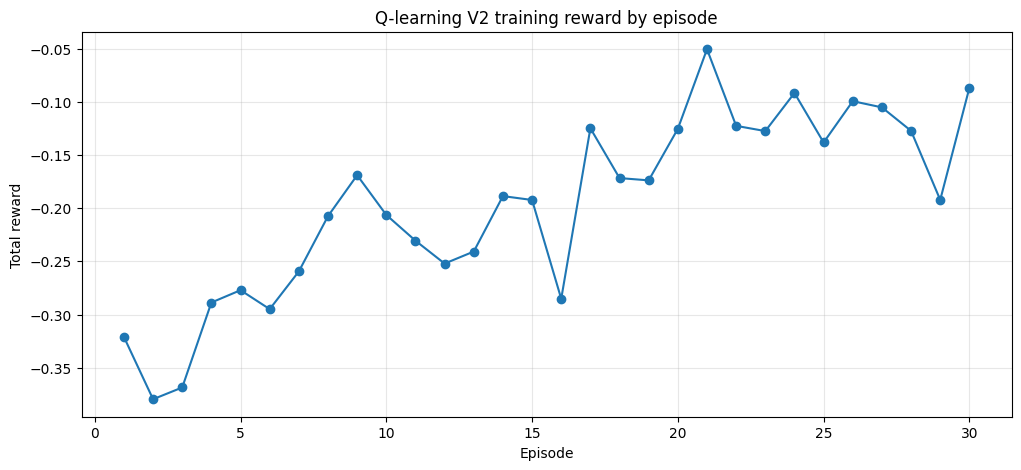

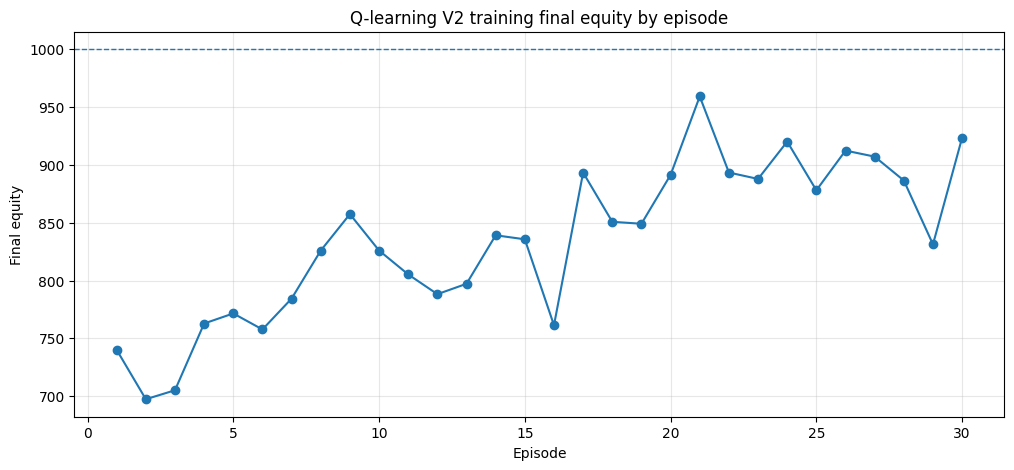

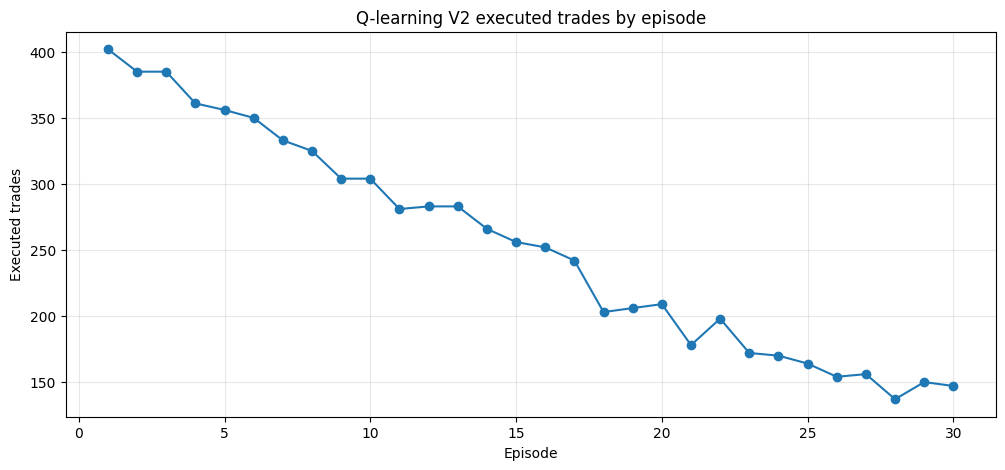

,episodes,mean_total_reward,best_total_reward,worst_total_reward,mean_final_equity,best_final_equity,worst_final_equity,mean_num_trades,mean_invalid_actions,mean_exposure
0,30,-0.196674,-0.050584,-0.379648,834.64651,959.172989,697.39902,253.733333,0.0,0.214607


In [9]:
# ============================================================
# Training diagnostics
# Se visualiza la evolución del reward, equity final, número de operaciones y exposición media durante el entrenamiento.
# Las gráficas se complementan con una tabla resumen para facilitar la interpretación posterior.
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(training_metrics_df["episode"], training_metrics_df["total_reward"], marker="o")
ax.set_title("Q-learning V2 training reward by episode")
ax.set_xlabel("Episode")
ax.set_ylabel("Total reward")
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(training_metrics_df["episode"], training_metrics_df["final_equity"], marker="o")
ax.axhline(INITIAL_BALANCE, linestyle="--", linewidth=1)
ax.set_title("Q-learning V2 training final equity by episode")
ax.set_xlabel("Episode")
ax.set_ylabel("Final equity")
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(training_metrics_df["episode"], training_metrics_df["num_trades"], marker="o")
ax.set_title("Q-learning V2 executed trades by episode")
ax.set_xlabel("Episode")
ax.set_ylabel("Executed trades")
ax.grid(True, alpha=0.3)
plt.show()

training_summary = {
    "episodes": len(training_metrics_df),
    "mean_total_reward": training_metrics_df["total_reward"].mean(),
    "best_total_reward": training_metrics_df["total_reward"].max(),
    "worst_total_reward": training_metrics_df["total_reward"].min(),
    "mean_final_equity": training_metrics_df["final_equity"].mean(),
    "best_final_equity": training_metrics_df["final_equity"].max(),
    "worst_final_equity": training_metrics_df["final_equity"].min(),
    "mean_num_trades": training_metrics_df["num_trades"].mean(),
    "mean_invalid_actions": training_metrics_df["invalid_actions"].mean(),
    "mean_exposure": training_metrics_df["mean_exposure"].mean(),
}

training_summary_df = pd.DataFrame([training_summary])
display(training_summary_df)


## Comentarios - Entrenamiento del agente Q-learning V2

El entrenamiento muestra una política todavía débil. El mejor `final_equity` de entrenamiento es 959.17, por debajo del capital inicial de 1.000, por lo que incluso el mejor episodio es simplemente el menos malo dentro de las ventanas de entrenamiento.

Ese `best_final_equity` pertenece a un episodio concreto de entrenamiento, con inicio aleatorio dentro del tramo train y un máximo de 2.000 pasos. No es la curva de equity del test ni un resultado previo directamente comparable al backtest final.

El `mean_num_trades` de 253.73 también debe leerse dentro de ese contexto: es la media de operaciones por episodio de entrenamiento de hasta 2.000 pasos. No se puede comparar directamente con los 13 trades del smoke test, que solo ejecuta 100 pasos aleatorios sin máscara.

La métrica más relevante para la evaluación final aparece después, en el backtest temporal sobre test. Ahí la política aprendida se congela, se elimina la exploración (`epsilon=0`) y se comprueba si la Q-table generaliza sobre datos posteriores no vistos.


In [10]:
# ============================================================
# Evaluate trained RL policy on temporal test set
# Se evalúa la política aprendida en el tramo de test sin exploración, usando siempre la acción válida con mayor valor Q estimado.
# La evaluación reproduce un backtest simplificado con costes, cooldown, position sizing parcial y sin acceso a información futura.
# ============================================================

test_env = DogeTradingEnv(
    test_scaled_df,
    feature_cols,
    initial_balance=INITIAL_BALANCE,
    fee_rate=FEE_RATE,
    slippage_rate=SLIPPAGE_RATE,
    position_size_pct=POSITION_SIZE_PCT,
    cooldown_steps=COOLDOWN_STEPS,
    trade_reward_penalty=TRADE_REWARD_PENALTY,
    invalid_action_penalty=INVALID_ACTION_PENALTY,
    random_start=False,
    max_episode_steps=None,
    seed=RANDOM_STATE,
)

obs, info = test_env.reset(seed=RANDOM_STATE)
state = discretize_observation(obs)
eval_records = []
done = False

while not done:
    valid_actions = test_env.get_valid_actions()
    action = choose_action(q_table, state, epsilon=0.0, valid_actions=valid_actions, n_actions=test_env.action_space.n)
    next_obs, reward, terminated, truncated, info = test_env.step(action)
    next_state = discretize_observation(next_obs)

    record = {
        "step": test_env.current_step,
        "action": action,
        "executed_action": info["executed_action"],
        "executed_trade": info["executed_trade"],
        "invalid_action": info["invalid_action"],
        "price": info["price"],
        "equity": info["equity"],
        "reward": reward,
        "position": info["position"],
        "exposure": info["exposure"],
        "cooldown_remaining": info["cooldown_remaining"],
    }

    if "open_time" in test_scaled_df.columns:
        record["open_time"] = test_scaled_df.loc[min(test_env.current_step, len(test_scaled_df) - 1), "open_time"]

    eval_records.append(record)
    state = next_state
    done = terminated or truncated

rl_eval_df = pd.DataFrame(eval_records)

if "open_time" in rl_eval_df.columns:
    rl_eval_df["open_time"] = pd.to_datetime(rl_eval_df["open_time"])

display(rl_eval_df.head())
display(rl_eval_df.tail())
print(f"Evaluation steps: {len(rl_eval_df)}")
print(f"Executed trades in test: {len(test_env.trade_log)}")
print(f"Invalid actions in test: {test_env.invalid_action_count}")


,step,action,executed_action,executed_trade,invalid_action,price,equity,reward,position,exposure,cooldown_remaining,open_time
0,1,0,0,HOLD,False,0.38310,1000.0,0.0,0,0.0,0,2025-01-06 07:00:00
1,2,0,0,HOLD,False,0.38295,1000.0,0.0,0,0.0,0,2025-01-06 07:05:00
2,3,0,0,HOLD,False,0.38286,1000.0,0.0,0,0.0,0,2025-01-06 07:10:00
3,4,0,0,HOLD,False,0.38148,1000.0,0.0,0,0.0,0,2025-01-06 07:15:00
4,5,0,0,HOLD,False,0.38122,1000.0,0.0,0,0.0,0,2025-01-06 07:20:00


,step,action,executed_action,executed_trade,invalid_action,price,equity,reward,position,exposure,cooldown_remaining,open_time
144610,144611,0,0,HOLD,False,0.09946,136.345883,0.0,0,0.0,0,2026-05-23 09:50:00
144611,144612,0,0,HOLD,False,0.09940,136.345883,0.0,0,0.0,0,2026-05-23 09:55:00
144612,144613,0,0,HOLD,False,0.09942,136.345883,0.0,0,0.0,0,2026-05-23 10:00:00
144613,144614,0,0,HOLD,False,0.09946,136.345883,0.0,0,0.0,0,2026-05-23 10:05:00
144614,144615,0,0,HOLD,False,0.09955,136.345883,0.0,0,0.0,0,2026-05-23 10:10:00


Evaluation steps: 144615
Executed trades in test: 3108
Invalid actions in test: 0


In [11]:
# ============================================================
# Buy and Hold benchmark
# Se calcula una estrategia Buy & Hold sobre el mismo tramo de test para comparar el agente RL contra una referencia pasiva sencilla.
# El benchmark aplica costes de entrada y salida para mantener coherencia con la simulación del agente.
# ============================================================

initial_price = float(test_df["close"].iloc[0])
final_price = float(test_df["close"].iloc[-1])

entry_price = initial_price * (1 + SLIPPAGE_RATE)
exit_price_series = test_df["close"].astype(float) * (1 - SLIPPAGE_RATE)

buy_hold_units = (INITIAL_BALANCE * (1 - FEE_RATE)) / entry_price
buy_hold_equity = buy_hold_units * exit_price_series * (1 - FEE_RATE)

buy_hold_df = pd.DataFrame({
    "equity": buy_hold_equity.to_numpy(),
    "price": test_df["close"].astype(float).to_numpy(),
})

if "open_time" in test_df.columns:
    buy_hold_df["open_time"] = test_df["open_time"].to_numpy()

buy_hold_return_pct = (buy_hold_df["equity"].iloc[-1] / INITIAL_BALANCE - 1) * 100

benchmark_summary_df = pd.DataFrame([{
    "initial_price": initial_price,
    "final_price": final_price,
    "buy_hold_final_equity": buy_hold_df["equity"].iloc[-1],
    "buy_hold_return_pct": buy_hold_return_pct,
}])

display(benchmark_summary_df)


,initial_price,final_price,buy_hold_final_equity,buy_hold_return_pct
0,0.38417,0.09955,258.353589,-74.164641


In [12]:
# ============================================================
# Financial and operational metrics helper functions
# Se definen funciones auxiliares para calcular drawdown, Sharpe ratio aproximado y métricas comparables de resultados.
# La V2 añade exposición media, exposición máxima, turnover y número de operaciones ejecutadas.
# ============================================================

def compute_drawdown(equity_series):
    equity_series = pd.Series(equity_series).astype(float)
    running_max = equity_series.cummax()
    drawdown = equity_series / running_max - 1
    return drawdown


def compute_sharpe_from_equity(equity_series, periods_per_year=105_120):
    equity_series = pd.Series(equity_series).astype(float)
    returns = equity_series.pct_change().replace([np.inf, -np.inf], np.nan).dropna()
    if returns.std() == 0 or len(returns) == 0:
        return np.nan
    return (returns.mean() / returns.std()) * np.sqrt(periods_per_year)


def summarize_strategy(
    equity_series,
    strategy_name,
    action_series=None,
    executed_trade_series=None,
    exposure_series=None,
    invalid_action_series=None,
):
    equity_series = pd.Series(equity_series).astype(float).reset_index(drop=True)
    drawdown = compute_drawdown(equity_series)

    if action_series is not None:
        action_series = pd.Series(action_series).reset_index(drop=True)

    if executed_trade_series is not None:
        executed_trade_series = pd.Series(executed_trade_series).reset_index(drop=True)
        number_of_trades = int((executed_trade_series != "HOLD").sum())
    else:
        number_of_trades = np.nan

    if exposure_series is not None:
        exposure_series = pd.Series(exposure_series).astype(float).reset_index(drop=True)
        mean_exposure = exposure_series.mean()
        max_exposure = exposure_series.max()
    else:
        mean_exposure = np.nan
        max_exposure = np.nan

    if invalid_action_series is not None:
        invalid_actions = int(pd.Series(invalid_action_series).sum())
    else:
        invalid_actions = np.nan

    return {
        "strategy": strategy_name,
        "initial_balance": INITIAL_BALANCE,
        "final_balance": equity_series.iloc[-1],
        "return_pct": (equity_series.iloc[-1] / INITIAL_BALANCE - 1) * 100,
        "max_drawdown_pct": drawdown.min() * 100,
        "sharpe_ratio_approx": compute_sharpe_from_equity(equity_series),
        "num_periods": len(equity_series),
        "number_of_trades": number_of_trades,
        "turnover": number_of_trades / len(equity_series) if len(equity_series) > 0 and not pd.isna(number_of_trades) else np.nan,
        "mean_exposure": mean_exposure,
        "max_exposure": max_exposure,
        "invalid_actions": invalid_actions,
        "buy_signals": int((action_series == 1).sum()) if action_series is not None else np.nan,
        "sell_signals": int((action_series == 2).sum()) if action_series is not None else np.nan,
        "hold_signals": int((action_series == 0).sum()) if action_series is not None else np.nan,
    }


In [13]:
# ============================================================
# Load V1 reference results
# Se cargan directamente los resultados guardados por el notebook 08 para reutilizar la curva y las métricas previamente obtenidas.
# La comparación no recalcula V1: normaliza los CSV persistidos en results y los alinea con el tramo de test actual.
# ============================================================

v1_summary_path = RESULTS_DIR / "08_baseline_RL_summary.csv"
v1_equity_path = RESULTS_DIR / "08_baseline_RL_equity_curve.csv"

required_v1_paths = [
    v1_summary_path,
    v1_equity_path,
]

missing_v1_paths = [path for path in required_v1_paths if not path.exists()]

if missing_v1_paths:
    missing_text = "\n".join(str(path) for path in missing_v1_paths)
    raise FileNotFoundError(
        "Missing RL V1 results. Execute notebook 08 first, or check ../results/:\n"
        f"{missing_text}"
    )

v1_summary_df = pd.read_csv(v1_summary_path)
v1_equity_raw_df = pd.read_csv(v1_equity_path)


def normalize_v1_reference_curve(reference_df, expected_len=None):
    reference_df = reference_df.copy().reset_index(drop=True)

    equity_candidates = [
        "rl_v1_equity",
        "rl_equity",
        "equity",
        "strategy_equity",
        "portfolio_value",
        "balance",
        "total_equity",
    ]

    drawdown_candidates = [
        "rl_v1_drawdown",
        "rl_drawdown",
        "drawdown",
        "strategy_drawdown",
    ]

    buy_hold_candidates = [
        "buy_hold_equity",
        "bh_equity",
        "benchmark_equity",
    ]

    equity_col = next((col for col in equity_candidates if col in reference_df.columns), None)
    drawdown_col = next((col for col in drawdown_candidates if col in reference_df.columns), None)
    buy_hold_col = next((col for col in buy_hold_candidates if col in reference_df.columns), None)

    if equity_col is None:
        raise KeyError(
            "Could not identify the V1 equity column in the persisted RL reference. "
            f"Available columns: {list(reference_df.columns)}"
        )

    normalized = pd.DataFrame({
        "rl_v1_equity": reference_df[equity_col].astype(float),
    })

    if drawdown_col is not None:
        normalized["rl_v1_drawdown"] = reference_df[drawdown_col].astype(float)
    else:
        normalized["rl_v1_drawdown"] = compute_drawdown(normalized["rl_v1_equity"])

    if buy_hold_col is not None:
        normalized["v1_buy_hold_equity"] = reference_df[buy_hold_col].astype(float)

    if "open_time" in reference_df.columns:
        normalized["open_time"] = pd.to_datetime(reference_df["open_time"])

    if expected_len is not None and len(normalized) != expected_len:
        min_len = min(len(normalized), expected_len)
        print(
            f"Warning: V1 reference length ({len(normalized)}) does not match current V2 test length ({expected_len}). "
            f"Using the last {min_len} aligned rows."
        )
        normalized = normalized.tail(min_len).reset_index(drop=True)

    return normalized


v1_reference_df = normalize_v1_reference_curve(v1_equity_raw_df, expected_len=len(rl_eval_df))

print("Loaded RL V1 summary:")
display(v1_summary_df)

print("Loaded RL V1 equity curve columns:")
display(pd.DataFrame({"columns": v1_equity_raw_df.columns}))

print("Normalized RL V1 reference preview:")
display(v1_reference_df.head())
display(v1_reference_df.tail())


Loaded RL V1 summary:


,notebook,strategy,initial_balance,final_balance,return_pct,max_drawdown_pct,sharpe_ratio_approx,num_periods,buy_signals,sell_signals,hold_signals,fees_applied,slippage_applied,position_sizing,main_limitation
0,08_baseline_RL,RL baseline,1000.0,6.646529,-99.335347,-99.398312,-7.406826,144615,15046.0,33602.0,95967.0,0.001,0.0005,All-in long-only when BUY is executed,Simplified tabular Q-learning baseline with di...
1,08_baseline_RL,Buy & Hold,1000.0,258.120019,-74.187998,-81.410760,-0.464415,144615,NaN,NaN,NaN,0.001,0.0005,All-in long-only when BUY is executed,Simplified tabular Q-learning baseline with di...


Loaded RL V1 equity curve columns:


,columns
0,rl_equity
1,buy_hold_equity
2,open_time
3,rl_drawdown
4,buy_hold_drawdown


Normalized RL V1 reference preview:


,rl_v1_equity,rl_v1_drawdown,v1_buy_hold_equity,open_time
0,1000.0,0.0,997.003498,2025-01-06 07:00:00
1,1000.0,0.0,994.226618,2025-01-06 07:05:00
2,1000.0,0.0,993.837336,2025-01-06 07:10:00
3,1000.0,0.0,993.603767,2025-01-06 07:15:00
4,1000.0,0.0,990.022371,2025-01-06 07:20:00


,rl_v1_equity,rl_v1_drawdown,v1_buy_hold_equity,open_time
144610,6.646529,-0.993941,258.249780,2026-05-23 09:50:00
144611,6.646529,-0.993941,258.120019,2026-05-23 09:55:00
144612,6.646529,-0.993941,257.964307,2026-05-23 10:00:00
144613,6.646529,-0.993941,258.016211,2026-05-23 10:05:00
144614,6.646529,-0.993941,258.120019,2026-05-23 10:10:00


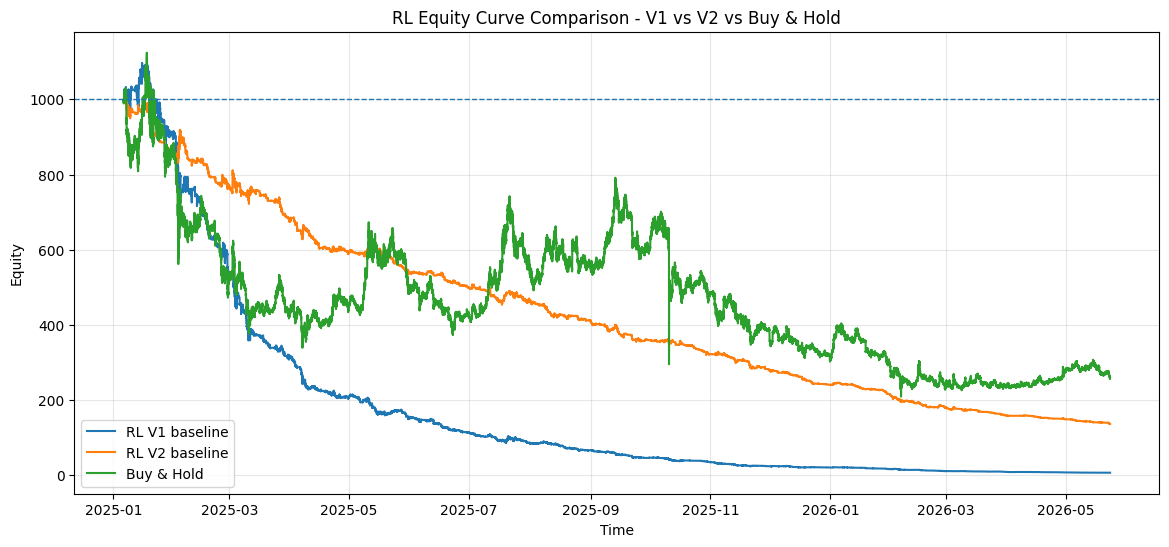

,notebook,strategy,initial_balance,final_balance,return_pct,max_drawdown_pct,sharpe_ratio_approx,number_of_trades,turnover,mean_exposure,max_exposure,invalid_actions,buy_signals,sell_signals,hold_signals,fees_applied,slippage_applied,position_sizing,main_limitation
0,08_baseline_RL,RL baseline,1000.0,6.646529,-99.335347,-99.398312,-7.406826,NaN,NaN,NaN,NaN,NaN,15046.0,33602.0,95967.0,0.001,0.0005,All-in long-only when BUY is executed,Simplified tabular Q-learning baseline with di...
1,09_baseline_RL_v2,RL V2 baseline,1000.0,136.345883,-86.365412,-86.393880,-6.973000,3108.0,0.021492,0.061642,0.536777,0.0,1554.0,1554.0,141507.0,0.001,0.0005,50% of available cash on BUY,Tabular Q-learning with simple discretized sta...
2,09_baseline_RL_v2,Buy & Hold,1000.0,258.353589,-74.164641,-81.410760,-0.461721,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001,0.0005,50% of available cash on BUY,Tabular Q-learning with simple discretized sta...


In [14]:
# ============================================================
# RL V1, RL V2 and Buy & Hold equity comparison
# Se comparan visualmente las curvas de equity de V1, V2 y Buy & Hold usando los resultados persistidos de V1 y la evaluación actual de V2.
# La tabla resume las métricas principales y evita duplicar el benchmark pasivo guardado por V1.
# ============================================================

rl_v2_equity = rl_eval_df["equity"].astype(float).reset_index(drop=True)
bh_equity = buy_hold_df["equity"].astype(float).reset_index(drop=True)

comparison_len = min(len(v1_reference_df), len(rl_v2_equity), len(bh_equity))

v1_reference_aligned = v1_reference_df.tail(comparison_len).reset_index(drop=True)
rl_eval_aligned = rl_eval_df.tail(comparison_len).reset_index(drop=True)
rl_v2_equity_aligned = rl_v2_equity.tail(comparison_len).reset_index(drop=True)
bh_equity_aligned = bh_equity.tail(comparison_len).reset_index(drop=True)

comparison_df = pd.DataFrame({
    "rl_v1_equity": v1_reference_aligned["rl_v1_equity"],
    "rl_v2_equity": rl_v2_equity_aligned,
    "buy_hold_equity": bh_equity_aligned,
})

if "open_time" in rl_eval_aligned.columns:
    comparison_df["open_time"] = pd.to_datetime(rl_eval_aligned["open_time"])
elif "open_time" in v1_reference_aligned.columns:
    comparison_df["open_time"] = pd.to_datetime(v1_reference_aligned["open_time"])

comparison_df["rl_v1_drawdown"] = compute_drawdown(comparison_df["rl_v1_equity"])
comparison_df["rl_v2_drawdown"] = compute_drawdown(comparison_df["rl_v2_equity"])
comparison_df["buy_hold_drawdown"] = compute_drawdown(comparison_df["buy_hold_equity"])

x_axis = comparison_df["open_time"] if "open_time" in comparison_df.columns else comparison_df.index

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(x_axis, comparison_df["rl_v1_equity"], label="RL V1 baseline")
ax.plot(x_axis, comparison_df["rl_v2_equity"], label="RL V2 baseline")
ax.plot(x_axis, comparison_df["buy_hold_equity"], label="Buy & Hold")
ax.axhline(INITIAL_BALANCE, linestyle="--", linewidth=1)
ax.set_title("RL Equity Curve Comparison - V1 vs V2 vs Buy & Hold")
ax.set_xlabel("Time" if "open_time" in comparison_df.columns else "Step")
ax.set_ylabel("Equity")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

summary_rows = [
    summarize_strategy(
        comparison_df["rl_v2_equity"],
        "RL V2 baseline",
        action_series=rl_eval_aligned["action"],
        executed_trade_series=rl_eval_aligned["executed_trade"],
        exposure_series=rl_eval_aligned["exposure"],
        invalid_action_series=rl_eval_aligned["invalid_action"],
    ),
    summarize_strategy(comparison_df["buy_hold_equity"], "Buy & Hold"),
]

results_summary_df = pd.DataFrame(summary_rows)
results_summary_df.insert(0, "notebook", NOTEBOOK_ID)
results_summary_df["fees_applied"] = FEE_RATE
results_summary_df["slippage_applied"] = SLIPPAGE_RATE
results_summary_df["position_sizing"] = f"{POSITION_SIZE_PCT:.0%} of available cash on BUY"
results_summary_df["cooldown_steps"] = COOLDOWN_STEPS
results_summary_df["trade_reward_penalty"] = TRADE_REWARD_PENALTY
results_summary_df["invalid_action_penalty"] = INVALID_ACTION_PENALTY
results_summary_df["main_limitation"] = "Tabular Q-learning with simple discretized state space and no market regime filters"

if "strategy" in v1_summary_df.columns:
    v1_strategy_summary_df = v1_summary_df[
        ~v1_summary_df["strategy"].astype(str).str.contains("Buy & Hold", case=False, na=False)
    ].copy()
else:
    v1_strategy_summary_df = v1_summary_df.copy()

rl_version_comparison_df = pd.concat(
    [v1_strategy_summary_df, results_summary_df],
    ignore_index=True,
    sort=False,
)

preferred_cols = [
    "notebook",
    "strategy",
    "initial_balance",
    "final_balance",
    "return_pct",
    "max_drawdown_pct",
    "sharpe_ratio_approx",
    "number_of_trades",
    "turnover",
    "mean_exposure",
    "max_exposure",
    "invalid_actions",
    "buy_signals",
    "sell_signals",
    "hold_signals",
    "fees_applied",
    "slippage_applied",
    "position_sizing",
    "main_limitation",
]

existing_cols = [col for col in preferred_cols if col in rl_version_comparison_df.columns]
rl_version_comparison_df = rl_version_comparison_df[existing_cols]

display(rl_version_comparison_df)


## Comentarios - Comparación RL V1 vs RL V2 vs Buy & Hold

La comparación se construye ahora con el mismo patrón usado en el bloque de backtesting supervisado: primero se cargan los resultados persistidos de la versión anterior y después se añaden al plot de equity junto con la estrategia actual y el benchmark pasivo.

Con la ejecución actual, V2 mejora claramente a V1: el balance final sube de 6.65 a 136.35 y el retorno pasa de -99.34 % a -86.37 %. También mejora el drawdown, de -99.40 % a -86.39 %.

La mejora sigue siendo insuficiente frente a Buy & Hold. El benchmark pasivo termina con 258.12 y un retorno del -74.19 %, mientras que RL V2 termina con 136.35 y un retorno del -86.37 %. Por tanto, la mejora de V2 es operativa y metodológica, no financiera.

Esta comparación visual es importante para la narrativa del TFM porque muestra progreso entre versiones sin ocultar que el agente sigue siendo peor que una referencia pasiva. La V3 debería repetir este patrón: cargar V1 y V2 desde `../results/`, añadir V3 y comparar todas las curvas en equity y drawdown.

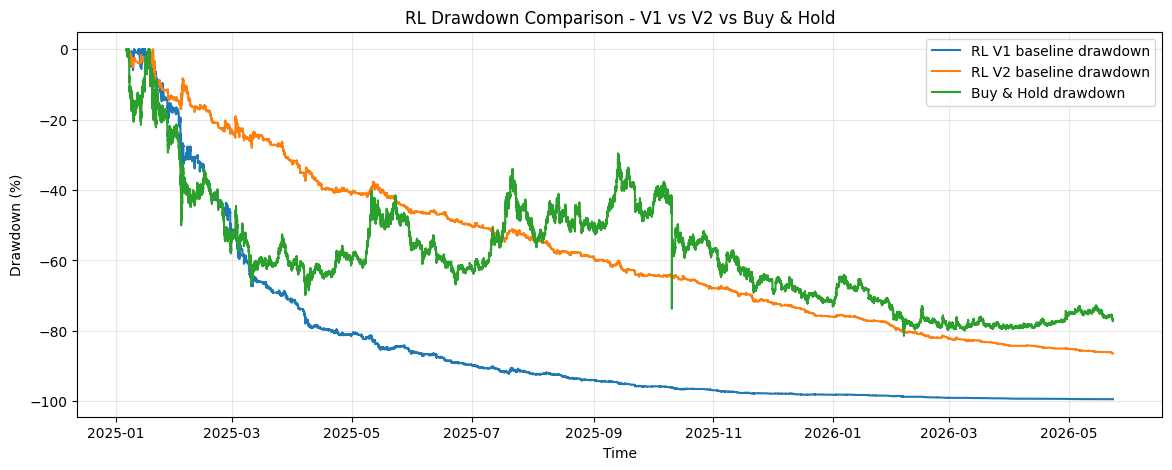

,rl_v1_max_drawdown_pct,rl_v2_max_drawdown_pct,buy_hold_max_drawdown_pct,rl_v1_final_equity,rl_v2_final_equity,buy_hold_final_equity
0,-99.398312,-86.39388,-81.41076,6.646529,136.345883,258.353589


In [15]:
# ============================================================
# Drawdown comparison
# Se calculan y visualizan los drawdowns acumulados de V1, V2 y Buy & Hold para comparar el riesgo temporal entre versiones.
# Este plot reutiliza la misma tabla `comparison_df` creada para la curva de equity, evitando comparaciones parciales o desalineadas.
# ============================================================

x_axis = comparison_df["open_time"] if "open_time" in comparison_df.columns else comparison_df.index

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(x_axis, comparison_df["rl_v1_drawdown"] * 100, label="RL V1 baseline drawdown")
ax.plot(x_axis, comparison_df["rl_v2_drawdown"] * 100, label="RL V2 baseline drawdown")
ax.plot(x_axis, comparison_df["buy_hold_drawdown"] * 100, label="Buy & Hold drawdown")
ax.set_title("RL Drawdown Comparison - V1 vs V2 vs Buy & Hold")
ax.set_xlabel("Time" if "open_time" in comparison_df.columns else "Step")
ax.set_ylabel("Drawdown (%)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

drawdown_summary_df = pd.DataFrame([{
    "rl_v1_max_drawdown_pct": comparison_df["rl_v1_drawdown"].min() * 100,
    "rl_v2_max_drawdown_pct": comparison_df["rl_v2_drawdown"].min() * 100,
    "buy_hold_max_drawdown_pct": comparison_df["buy_hold_drawdown"].min() * 100,
    "rl_v1_final_equity": comparison_df["rl_v1_equity"].iloc[-1],
    "rl_v2_final_equity": comparison_df["rl_v2_equity"].iloc[-1],
    "buy_hold_final_equity": comparison_df["buy_hold_equity"].iloc[-1],
}])

display(drawdown_summary_df)


## Comentarios - Drawdown

El drawdown se interpreta mejor cuando se muestra junto a V1 y Buy & Hold. Con la ejecución actual, RL V2 mejora de forma clara el colapso extremo de V1, pero sigue manteniendo un deterioro superior al benchmark pasivo.

El drawdown máximo de RL V2 alcanza -86.39 %, frente al -99.40 % de V1 y al -81.41 % de Buy & Hold. Esto confirma que el position sizing parcial, el cooldown y la penalización por operar reducen parte del comportamiento degenerado, pero no equivalen a una gestión de riesgo real.

La lectura metodológica es directa: V2 reduce el daño respecto a V1, pero no lo controla suficientemente. Esto justifica que V3 introduzca filtros de régimen, penalización explícita por drawdown y reglas defensivas como stop-loss o take-profit.

In [16]:
# ============================================================
# Action distribution, exposure and trade log
# Se resume la distribución de acciones, operaciones ejecutadas, exposición y turnover para detectar políticas degeneradas o exceso de rotación.
# Esto ayuda a interpretar si las restricciones de V2 reducen señales inválidas y cambios de posición innecesarios.
# ============================================================

action_label_map = {0: "HOLD", 1: "BUY", 2: "SELL"}

action_distribution_df = (
    rl_eval_df["action"]
    .map(action_label_map)
    .value_counts()
    .rename_axis("action")
    .reset_index(name="count")
)

action_distribution_df["pct"] = action_distribution_df["count"] / action_distribution_df["count"].sum() * 100

executed_trade_distribution_df = (
    rl_eval_df["executed_trade"]
    .value_counts()
    .rename_axis("executed_trade")
    .reset_index(name="count")
)

executed_trade_distribution_df["pct"] = executed_trade_distribution_df["count"] / executed_trade_distribution_df["count"].sum() * 100

operational_summary_df = pd.DataFrame([{
    "requested_actions": len(rl_eval_df),
    "executed_trades": int((rl_eval_df["executed_trade"] != "HOLD").sum()),
    "invalid_actions": int(rl_eval_df["invalid_action"].sum()),
    "turnover": int((rl_eval_df["executed_trade"] != "HOLD").sum()) / len(rl_eval_df),
    "mean_exposure": rl_eval_df["exposure"].mean(),
    "max_exposure": rl_eval_df["exposure"].max(),
    "mean_cooldown_remaining": rl_eval_df["cooldown_remaining"].mean(),
}])

display(action_distribution_df)
display(executed_trade_distribution_df)
display(operational_summary_df)

trade_log_df = pd.DataFrame(test_env.trade_log)

if not trade_log_df.empty and "open_time" in test_df.columns:
    trade_log_df["open_time"] = trade_log_df["step"].apply(lambda idx: test_df.loc[min(idx, len(test_df) - 1), "open_time"])
    trade_log_df = trade_log_df[["open_time", "step", "action", "price"]]

display(trade_log_df.head(20))
print(f"Executed trades in test: {len(trade_log_df)}")


,action,count,pct
0,HOLD,141507,97.850845
1,BUY,1554,1.074577
2,SELL,1554,1.074577


,executed_trade,count,pct
0,HOLD,141507,97.850845
1,BUY,1554,1.074577
2,SELL,1554,1.074577


,requested_actions,executed_trades,invalid_actions,turnover,mean_exposure,max_exposure,mean_cooldown_remaining
0,144615,3108,0,0.021492,0.061642,0.536777,0.128949


,open_time,step,action,price
0,2025-01-06 20:45:00,166,BUY,0.38781
1,2025-01-06 22:35:00,188,SELL,0.38780
2,2025-01-07 15:05:00,386,BUY,0.37190
3,2025-01-07 19:15:00,436,SELL,0.35509
4,2025-01-07 22:15:00,472,BUY,0.35017
5,2025-01-07 23:25:00,486,SELL,0.35115
6,2025-01-08 01:20:00,509,BUY,0.35034
7,2025-01-08 06:10:00,567,SELL,0.34970
8,2025-01-08 06:50:00,575,BUY,0.34149
9,2025-01-08 11:10:00,627,SELL,0.34795


Executed trades in test: 3108


## Comentarios - Distribución de acciones y operaciones

La política evaluada en test ejecuta 144.615 decisiones. La distribución queda dominada por HOLD, con 141.507 acciones (97.85 %), frente a 1.554 BUY (1.07 %) y 1.554 SELL (1.07 %).

La igualdad exacta entre BUY y SELL indica que el agente abre y cierra posiciones de forma equilibrada, sin quedarse atrapado permanentemente en posición al final del backtest. Además, las acciones solicitadas y las operaciones ejecutadas coinciden, y las acciones inválidas son 0. Esto confirma que la máscara de acciones válidas funciona como esperaba.

Aun así, 3.108 operaciones en el periodo de test siguen siendo muchas para una política que pierde más que Buy & Hold. El turnover medio es bajo en términos relativos (0.0215) y la exposición media queda en 0.0616, pero el agente no está usando esa menor exposición para proteger capital de forma efectiva.

La conclusión local es que V2 corrige el problema de acciones inválidas y reduce exposición, pero la calidad de las entradas y salidas sigue siendo pobre. El simio lleva casco, sí; pero sigue cruzando la autopista mirando una vela de 5 minutos.

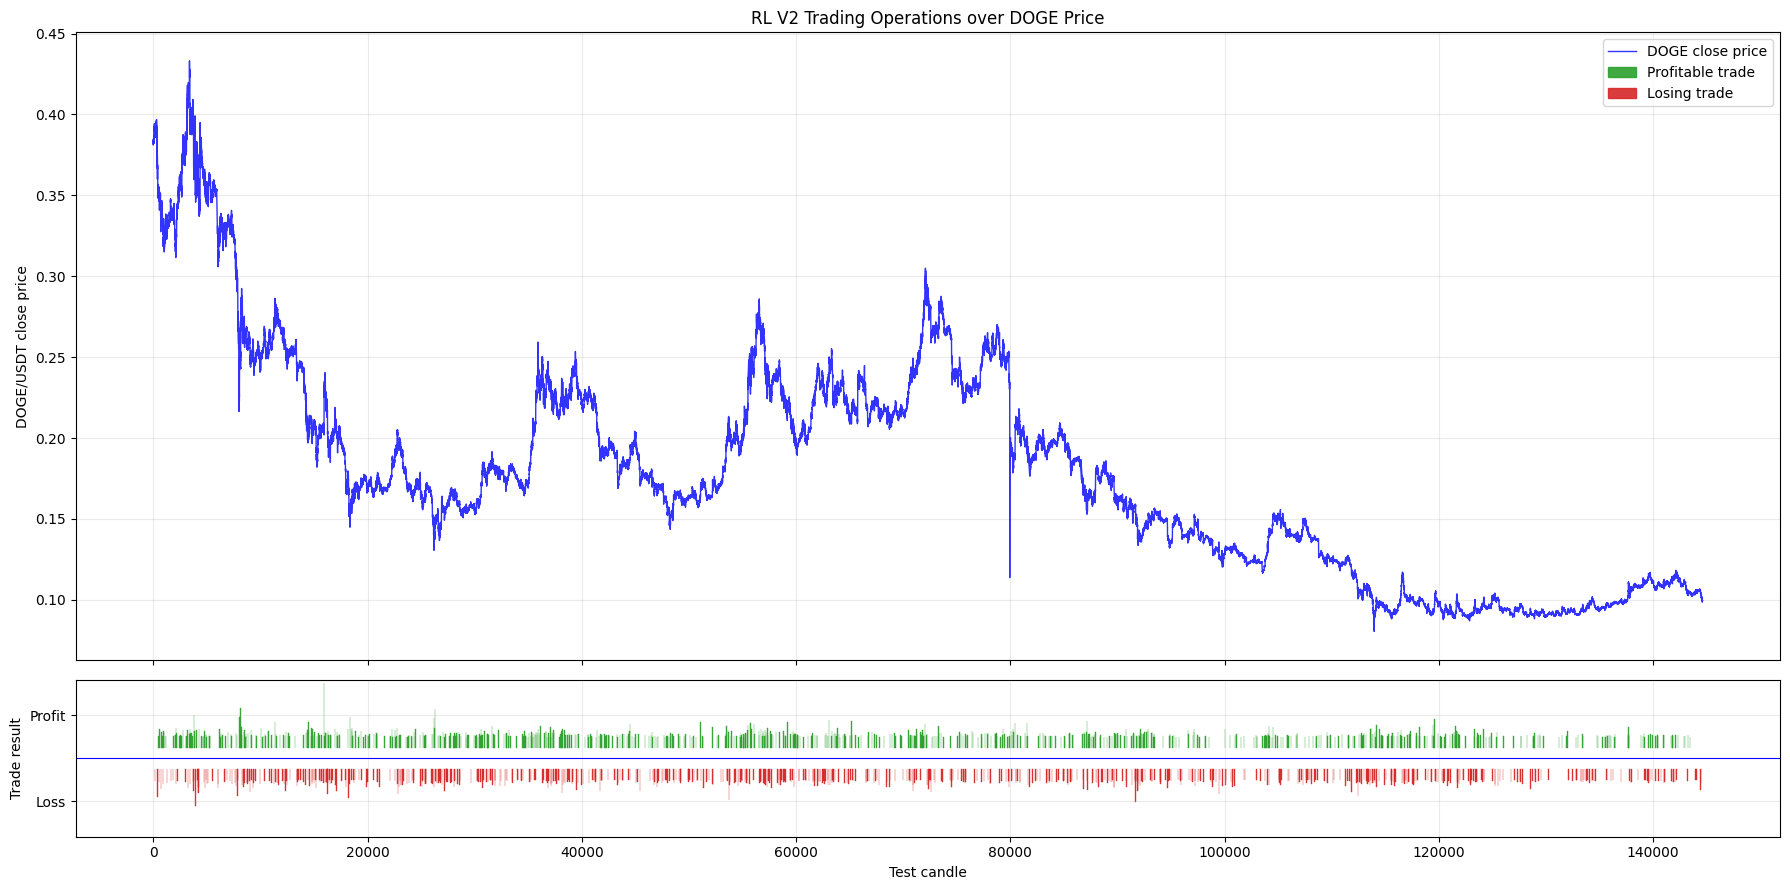

First RL V2 trade events:


,open_time,step,price,action,executed_action,executed_trade,equity,reward,position,exposure,cooldown_remaining,invalid_action
166,2025-01-06 20:50:00,167,0.38894,1,1,BUY,1000.705090,0.000655,1,0.500352,3,False
188,2025-01-06 22:40:00,189,0.38761,2,2,SELL,998.488895,-0.000799,0,0.000000,3,False
386,2025-01-07 15:10:00,387,0.36997,1,1,BUY,995.153424,-0.003396,1,0.498324,3,False
436,2025-01-07 19:20:00,437,0.35306,2,2,SELL,974.494516,-0.000782,0,0.000000,3,False
472,2025-01-07 22:20:00,473,0.35049,1,1,BUY,974.208610,-0.000343,1,0.499853,3,False
486,2025-01-07 23:30:00,487,0.35140,2,2,SELL,974.394023,-0.000801,0,0.000000,3,False
509,2025-01-08 01:25:00,510,0.34999,1,1,BUY,973.177598,-0.001299,1,0.499375,3,False
567,2025-01-08 06:15:00,568,0.34794,2,2,SELL,972.046793,-0.000799,0,0.000000,3,False
575,2025-01-08 06:55:00,576,0.34086,1,1,BUY,970.422823,-0.001722,1,0.499163,3,False
627,2025-01-08 11:15:00,628,0.34841,2,2,SELL,979.757025,-0.000806,0,0.000000,3,False


Last RL V2 trade events:


,open_time,step,price,action,executed_action,executed_trade,equity,reward,position,exposure,cooldown_remaining,invalid_action
143463,2026-05-19 10:15:00,143464,0.10414,1,1,BUY,140.228152,-0.001136,1,0.499457,3,False
143472,2026-05-19 11:00:00,143473,0.10419,2,2,SELL,140.170137,-0.000799,0,0.000000,3,False
143944,2026-05-21 02:20:00,143945,0.10509,1,1,BUY,139.978601,-0.001417,1,0.499316,3,False
143950,2026-05-21 02:50:00,143951,0.10508,2,2,SELL,139.853874,-0.000799,0,0.000000,3,False
144052,2026-05-21 11:20:00,144053,0.10441,1,1,BUY,139.715615,-0.001039,1,0.499505,3,False
144058,2026-05-21 11:50:00,144059,0.10433,2,2,SELL,139.577597,-0.000799,0,0.000000,3,False
144372,2026-05-22 14:00:00,144373,0.10618,1,1,BUY,139.250542,-0.002396,1,0.498826,3,False
144439,2026-05-22 19:35:00,144440,0.10323,2,2,SELL,137.212889,-0.000788,0,0.000000,3,False
144491,2026-05-22 23:55:00,144492,0.10234,1,1,BUY,137.083266,-0.000995,1,0.499527,3,False
144496,2026-05-23 00:20:00,144497,0.10156,2,2,SELL,136.345883,-0.000796,0,0.000000,3,False


Completed RL V2 trades:


,entry_idx,exit_idx,entry_time,exit_time,entry_price,exit_price,pnl_pct,duration_bars,result
0,166,188,2025-01-06 20:50:00,2025-01-06 22:40:00,0.38894,0.38761,-0.341955,22,LOSS
1,386,436,2025-01-07 15:10:00,2025-01-07 19:20:00,0.36997,0.35306,-4.570641,50,LOSS
2,472,486,2025-01-07 22:20:00,2025-01-07 23:30:00,0.35049,0.35140,0.259637,14,PROFIT
3,509,567,2025-01-08 01:25:00,2025-01-08 06:15:00,0.34999,0.34794,-0.585731,58,LOSS
4,575,627,2025-01-08 06:55:00,2025-01-08 11:15:00,0.34086,0.34841,2.214986,52,PROFIT
...,...,...,...,...,...,...,...,...,...
1549,143463,143472,2026-05-19 10:15:00,2026-05-19 11:00:00,0.10414,0.10419,0.048012,9,PROFIT
1550,143944,143950,2026-05-21 02:20:00,2026-05-21 02:50:00,0.10509,0.10508,-0.009516,6,LOSS
1551,144052,144058,2026-05-21 11:20:00,2026-05-21 11:50:00,0.10441,0.10433,-0.076621,6,LOSS
1552,144372,144439,2026-05-22 14:00:00,2026-05-22 19:35:00,0.10618,0.10323,-2.778301,67,LOSS


Open position status at the end of the test:


,has_open_position_at_end,open_entry_idx,open_entry_time,open_entry_price
0,False,None,None,None


,num_test_candles,num_trade_events,trade_event_share_%,num_buy_events,num_sell_events,num_hold_events,num_completed_trades,profitable_trades,losing_trades,win_rate_%,avg_trade_pnl_%,median_trade_pnl_%,avg_trade_duration_bars,avg_candles_per_trade_event,mean_exposure,max_exposure
0,144615,3108,2.149155,1554,1554,141507,1554,801,753,51.544402,0.047607,0.021036,11.482625,46.529923,0.061642,0.536777


In [17]:
# ============================================================
# Trading operations timeline
# Esta visualización muestra operaciones completas ejecutadas por RL V2 usando un panel de precio y un panel de resultados operativos.
# También se muestran tablas de operaciones y resúmenes para analizar frecuencia, duración y resultado de las entradas y salidas ejecutadas.
# ============================================================

import matplotlib.patches as patches

action_timeline_df = rl_eval_aligned.copy().reset_index(drop=True)

price_col = "price" if "price" in action_timeline_df.columns else "close"
price_series = action_timeline_df[price_col].astype(float).reset_index(drop=True)

if "open_time" in action_timeline_df.columns:
    action_timeline_df["open_time"] = pd.to_datetime(action_timeline_df["open_time"])

trade_rows = []
position_open = False
entry_idx = None
entry_price = None
entry_time = None

for i, row in action_timeline_df.iterrows():
    action = row["executed_trade"]
    price_i = float(row[price_col])
    time_i = row["open_time"] if "open_time" in action_timeline_df.columns else None

    if action == "BUY" and not position_open:
        position_open = True
        entry_idx = i
        entry_price = price_i
        entry_time = time_i

    elif action == "SELL" and position_open:
        exit_idx = i
        exit_price = price_i
        exit_time = time_i

        # PnL bruto aproximado entre precio de entrada y salida. La evolución completa del portfolio ya está recogida en la curva de equity.
        pnl_pct = (exit_price / entry_price - 1) * 100

        trade_rows.append({
            "entry_idx": entry_idx,
            "exit_idx": exit_idx,
            "entry_time": entry_time,
            "exit_time": exit_time,
            "entry_price": entry_price,
            "exit_price": exit_price,
            "pnl_pct": pnl_pct,
            "duration_bars": exit_idx - entry_idx,
            "result": "PROFIT" if pnl_pct >= 0 else "LOSS",
        })

        position_open = False
        entry_idx = None
        entry_price = None
        entry_time = None

trades_v2_df = pd.DataFrame(trade_rows)

open_position_summary_df = pd.DataFrame([{
    "has_open_position_at_end": bool(position_open),
    "open_entry_idx": entry_idx,
    "open_entry_time": entry_time,
    "open_entry_price": entry_price,
}])

x = np.arange(len(price_series))

fig, (ax_price, ax_trades) = plt.subplots(
    2,
    1,
    figsize=(18, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [4, 1]}
)

# ============================================================
# Price series
# ============================================================

ax_price.plot(
    x,
    price_series,
    color="blue",
    linewidth=1.0,
    alpha=0.8,
    label="DOGE close price"
)

ax_price.set_title("RL V2 Trading Operations over DOGE Price")
ax_price.set_ylabel("DOGE/USDT close price")
ax_price.grid(alpha=0.25)

# ============================================================
# Trade activity blocks
# ============================================================

if not trades_v2_df.empty:

    max_abs_pnl = max(trades_v2_df["pnl_pct"].abs().max(), 1e-9)

    for _, trade in trades_v2_df.iterrows():

        entry_idx_i = int(trade["entry_idx"])
        exit_idx_i = int(trade["exit_idx"])

        actual_width = max(exit_idx_i - entry_idx_i, 1)
        visual_width = max(actual_width, 45)

        x_start = entry_idx_i - (visual_width - actual_width) / 2

        pnl_scaled = abs(trade["pnl_pct"]) / max_abs_pnl
        height = 0.15 + pnl_scaled * 0.75

        if trade["result"] == "PROFIT":
            y_base = 0.15
            color = "tab:green"

        else:
            y_base = -0.15 - height
            color = "tab:red"

        rect = patches.Rectangle(
            (x_start, y_base),
            visual_width,
            height,
            linewidth=0.3,
            edgecolor=color,
            facecolor=color,
            alpha=0.9
        )

        ax_trades.add_patch(rect)

ax_trades.axhline(0, color="blue", linewidth=0.8)

ax_trades.set_ylim(-1.1, 1.1)
ax_trades.set_ylabel("Trade result")
ax_trades.set_xlabel("Test candle")
ax_trades.set_yticks([-0.6, 0.6])
ax_trades.set_yticklabels(["Loss", "Profit"])
ax_trades.grid(alpha=0.25)

legend_handles = [
    patches.Patch(facecolor="tab:green", edgecolor="tab:green", alpha=0.9, label="Profitable trade"),
    patches.Patch(facecolor="tab:red", edgecolor="tab:red", alpha=0.9, label="Losing trade"),
]

price_handles, price_labels = ax_price.get_legend_handles_labels()

ax_price.legend(
    handles=price_handles + legend_handles,
    loc="upper right"
)

plt.tight_layout()
plt.show()

# ============================================================
# Trade events and activity summaries
# ============================================================

trade_event_cols = [
    "open_time",
    "step",
    "price",
    "action",
    "executed_action",
    "executed_trade",
    "equity",
    "reward",
    "position",
    "exposure",
    "cooldown_remaining",
    "invalid_action",
]

trade_event_cols = [col for col in trade_event_cols if col in action_timeline_df.columns]

trade_events_v2_df = action_timeline_df.loc[
    action_timeline_df["executed_trade"].isin(["BUY", "SELL"]),
    trade_event_cols
].copy()

print("First RL V2 trade events:")
display(trade_events_v2_df.head(10))

print("Last RL V2 trade events:")
display(trade_events_v2_df.tail(10))

print("Completed RL V2 trades:")
display(trades_v2_df)

print("Open position status at the end of the test:")
display(open_position_summary_df)

trade_frequency_summary_df = pd.DataFrame([{
    "num_test_candles": len(action_timeline_df),
    "num_trade_events": len(trade_events_v2_df),
    "trade_event_share_%": len(trade_events_v2_df) / len(action_timeline_df) * 100 if len(action_timeline_df) > 0 else np.nan,
    "num_buy_events": int((action_timeline_df["executed_trade"] == "BUY").sum()),
    "num_sell_events": int((action_timeline_df["executed_trade"] == "SELL").sum()),
    "num_hold_events": int((action_timeline_df["executed_trade"] == "HOLD").sum()),
    "num_completed_trades": len(trades_v2_df),
    "profitable_trades": int((trades_v2_df["pnl_pct"] >= 0).sum()) if len(trades_v2_df) > 0 else 0,
    "losing_trades": int((trades_v2_df["pnl_pct"] < 0).sum()) if len(trades_v2_df) > 0 else 0,
    "win_rate_%": (trades_v2_df["pnl_pct"] >= 0).mean() * 100 if len(trades_v2_df) > 0 else np.nan,
    "avg_trade_pnl_%": trades_v2_df["pnl_pct"].mean() if len(trades_v2_df) > 0 else np.nan,
    "median_trade_pnl_%": trades_v2_df["pnl_pct"].median() if len(trades_v2_df) > 0 else np.nan,
    "avg_trade_duration_bars": trades_v2_df["duration_bars"].mean() if len(trades_v2_df) > 0 else np.nan,
    "avg_candles_per_trade_event": len(action_timeline_df) / len(trade_events_v2_df) if len(trade_events_v2_df) > 0 else np.nan,
    "mean_exposure": action_timeline_df["exposure"].mean() if "exposure" in action_timeline_df.columns else np.nan,
    "max_exposure": action_timeline_df["exposure"].max() if "exposure" in action_timeline_df.columns else np.nan,
}])

display(trade_frequency_summary_df)



## Comentarios - Operaciones sobre el precio

El `pnl_pct` mostrado en `trades_v2_df` es una aproximación bruta basada en el precio de entrada y salida. La lectura financiera principal sigue siendo la curva de equity, porque ahí se reflejan capital, posición, fees, slippage y exposición.

La tabla de eventos permite revisar las primeras y últimas operaciones ejecutadas, mientras que `trade_frequency_summary_df` resume frecuencia operativa, número de trades completados, win rate, duración media y exposición. Esta celda debe interpretarse junto con la equity curve y el drawdown: una política puede cerrar muchas operaciones de forma ordenada y aun así destruir capital si las entradas y salidas no tienen ventaja estadística.

In [18]:
# ============================================================
# Persist RL V2 results
# Se guardan los resultados principales del baseline RL V2 en la carpeta results para facilitar comparaciones posteriores entre notebooks.
# También se exportan la comparación V1-V2-Buy & Hold, el backtest detallado de V2, el log de operaciones y la configuración del experimento.
# ============================================================

summary_path = RESULTS_DIR / "09_baseline_RL_v2_summary.csv"
equity_path = RESULTS_DIR / "09_baseline_RL_v2_equity_curve.csv"
backtest_path = RESULTS_DIR / "09_baseline_RL_v2_backtest.csv"
trades_path = RESULTS_DIR / "09_baseline_RL_v2_trades.csv"
training_path = RESULTS_DIR / "09_baseline_RL_v2_training_metrics.csv"
comparison_path = RESULTS_DIR / "09_baseline_RL_v2_version_comparison.csv"
actions_timeline_path = RESULTS_DIR / "09_baseline_RL_v2_action_timeline.csv"
completed_trades_path = RESULTS_DIR / "09_baseline_RL_v2_completed_trades.csv"
trade_frequency_path = RESULTS_DIR / "09_baseline_RL_v2_trade_frequency_summary.csv"
config_path = RESULTS_DIR / "09_baseline_RL_v2_config.json"

rl_v2_backtest_df = rl_eval_aligned.copy().reset_index(drop=True)
rl_v2_backtest_df["rl_v2_equity"] = comparison_df["rl_v2_equity"]
rl_v2_backtest_df["rl_v2_drawdown"] = comparison_df["rl_v2_drawdown"]

results_summary_df.to_csv(summary_path, index=False)
comparison_df.to_csv(equity_path, index=False)
rl_v2_backtest_df.to_csv(backtest_path, index=False)
trade_log_df.to_csv(trades_path, index=False)
training_metrics_df.to_csv(training_path, index=False)
rl_version_comparison_df.to_csv(comparison_path, index=False)
action_timeline_df.to_csv(actions_timeline_path, index=False)

if "trades_v2_df" in globals():
    trades_v2_df.to_csv(completed_trades_path, index=False)

if "trade_frequency_summary_df" in globals():
    trade_frequency_summary_df.to_csv(trade_frequency_path, index=False)

config = {
    "notebook": NOTEBOOK_ID,
    "data_path": str(DATA_PATH),
    "gym_backend": GYM_BACKEND,
    "initial_balance": INITIAL_BALANCE,
    "fee_rate": FEE_RATE,
    "slippage_rate": SLIPPAGE_RATE,
    "train_fraction": TRAIN_FRACTION,
    "n_episodes": N_EPISODES,
    "max_train_episode_steps": MAX_TRAIN_EPISODE_STEPS,
    "position_size_pct": POSITION_SIZE_PCT,
    "cooldown_steps": COOLDOWN_STEPS,
    "trade_reward_penalty": TRADE_REWARD_PENALTY,
    "invalid_action_penalty": INVALID_ACTION_PENALTY,
    "feature_cols": feature_cols,
    "selected_state_features": selected_state_features,
    "rl_algorithm": "Tabular Q-learning with discretized state space and valid-action masking",
    "loaded_reference_results": [str(v1_summary_path), str(v1_equity_path)],
}

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=4, ensure_ascii=False, default=str)

saved_files_df = pd.DataFrame({
    "file": [
        summary_path,
        equity_path,
        backtest_path,
        trades_path,
        training_path,
        comparison_path,
        actions_timeline_path,
        completed_trades_path,
        trade_frequency_path,
        config_path,
    ]
})

display(saved_files_df)



,file
0,..\results\09_baseline_RL_v2_summary.csv
1,..\results\09_baseline_RL_v2_equity_curve.csv
2,..\results\09_baseline_RL_v2_backtest.csv
3,..\results\09_baseline_RL_v2_trades.csv
4,..\results\09_baseline_RL_v2_training_metrics.csv
5,..\results\09_baseline_RL_v2_version_compariso...
6,..\results\09_baseline_RL_v2_action_timeline.csv
7,..\results\09_baseline_RL_v2_completed_trades.csv
8,..\results\09_baseline_RL_v2_trade_frequency_s...
9,..\results\09_baseline_RL_v2_config.json


## Limitaciones del experimento

Este experimento mejora la V1 desde el punto de vista operativo, pero mantiene limitaciones importantes:

- El entorno sigue siendo long-only y no contempla posiciones cortas
- El agente solo puede abrir una posición parcial y cerrarla completa
- El cooldown es una regla fija, no aprendida ni optimizada
- La penalización por operación es manual y sensible a escala
- La discretización del estado reduce mucha información continua del mercado
- El reward no incorpora penalización directa por drawdown
- No se aplican filtros de tendencia, volatilidad ni régimen de mercado
- El entrenamiento se limita a pocos episodios para mantener bajo el coste computacional
- La simulación no modela profundidad de mercado, liquidez real ni latencia de ejecución

La comparación progresiva con V1 ayuda a visualizar la mejora, pero no debe confundirse con validación financiera. V2 reduce el colapso respecto a la baseline inicial, pero sigue perdiendo más que Buy & Hold.

## Conclusiones - Baseline RL V2

La V2 cumple su objetivo metodológico: introduce restricciones operativas mínimas sobre la baseline RL inicial y reduce comportamientos poco realistas. La máscara de acciones válidas elimina acciones inválidas durante entrenamiento y evaluación, el position sizing parcial reduce exposición y el cooldown limita parte de la rotación.

El smoke test muestra acciones inválidas porque usa acciones aleatorias sin máscara para probar las defensas internas del entorno. Esa cifra no debe confundirse con el backtest final, donde la política evaluada usa `get_valid_actions()` y termina con 0 acciones inválidas.

La comparación progresiva se ha reorganizado para seguir el patrón del bloque de backtesting supervisado: V2 carga los resultados persistidos de V1 desde `../results/`, añade su propia evaluación y representa V1, V2 y Buy & Hold en las curvas de equity y drawdown.

Los resultados financieros siguen siendo negativos. En test, RL V2 termina con 136.35 sobre un capital inicial de 1.000, lo que supone un retorno del -86.37 %. Buy & Hold también pierde durante el mismo periodo, pero termina en 258.12 y obtiene un retorno menos malo del -74.19 %.

La comparación contra V1 es útil para la narrativa del TFM. V1 terminaba prácticamente destruida, con 6.65 de balance final y -99.34 % de retorno. V2 no resuelve el problema de rentabilidad, pero sí reduce el colapso extremo y deja una política más controlada y más interpretable.

El drawdown confirma la limitación principal: RL V2 alcanza -86.39 %, todavía peor que Buy & Hold. Esto indica que las restricciones operativas reducen la degeneración, pero no sustituyen una gestión real del riesgo.

La siguiente iteración queda justificada: V3 debe introducir filtros de mercado, control explícito de drawdown y reglas defensivas como stop-loss o take-profit. No para prometer rentabilidad, sino para comprobar si el entorno RL responde mejor cuando el riesgo forma parte directa del diseño experimental.